#  CREDIT CARD FRAUD DETECTION

**Problem Statement:** Detect the fraud in Credit Card.

**Dataset:** Fraud Detection Dataset ( Keggle link : https://www.kaggle.com/datasets/miadul/credit-card-fraud-detection-dataset )

This notebook demonstrates the full project structure:
1. EDA
2. Cleaning & Preprocessing
3. Train Multiple ML models
4. Compare models using metrics
5. Select & justify the best model
6. Hyper-Parameter Tuning the Best Model
7. Predict on unseen data


## 1. Importing Libraries

In [208]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,roc_auc_score,f1_score,classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

## 2. Loading Dataset

In [ ]:
df = pd.read_csv("../datasets/credit_card_fraud_10k.csv")
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


## 3. Data Preperation

In [171]:
df.shape

(10000, 10)

In [172]:
df = df.drop(columns=['transaction_id'], axis=1)
df.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,Electronics,0,0,66,3,40,0
1,541.82,3,Travel,1,0,87,1,64,0
2,237.01,17,Grocery,0,0,49,1,61,0
3,164.33,4,Grocery,0,1,72,3,34,0
4,30.53,15,Food,0,0,79,0,44,0


## 4. EDA

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   amount               10000 non-null  float64
 1   transaction_hour     10000 non-null  int64  
 2   merchant_category    10000 non-null  object 
 3   foreign_transaction  10000 non-null  int64  
 4   location_mismatch    10000 non-null  int64  
 5   device_trust_score   10000 non-null  int64  
 6   velocity_last_24h    10000 non-null  int64  
 7   cardholder_age       10000 non-null  int64  
 8   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 703.3+ KB


In [174]:
df.describe()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [175]:
df.merchant_category.describe()

count     10000
unique        5
top        Food
freq       2093
Name: merchant_category, dtype: object

In [176]:
df.isnull().sum()

amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [177]:
df.duplicated().sum()

np.int64(0)

In [178]:
df.is_fraud.value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

Target Class is Highly Imbalanced.

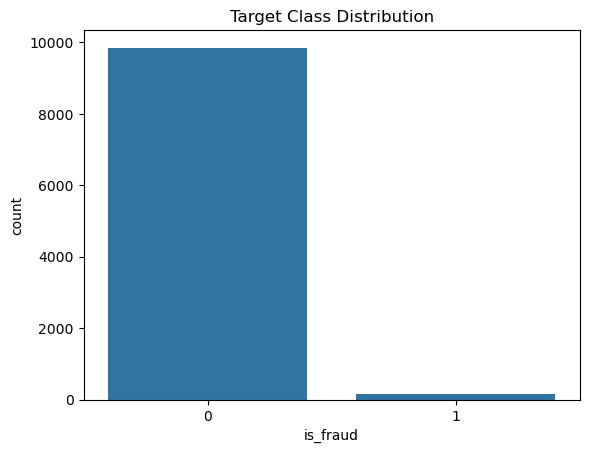

In [179]:
sns.countplot(x=df.is_fraud)
plt.title("Target Class Distribution")
plt.show()

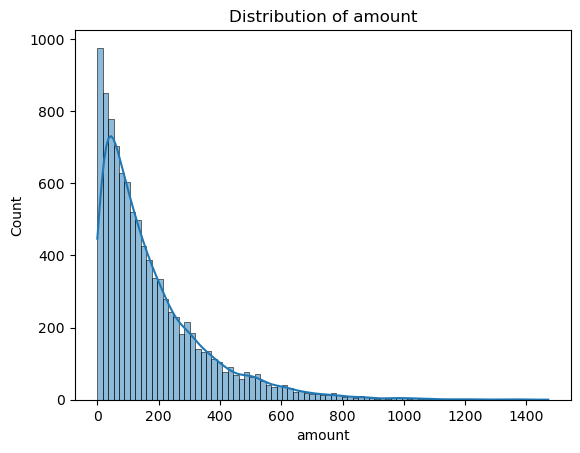

Skewness of amount = 1.92


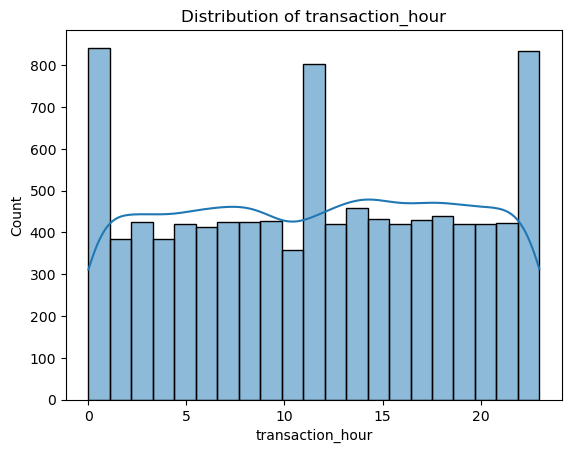

Skewness of transaction_hour = -0.03


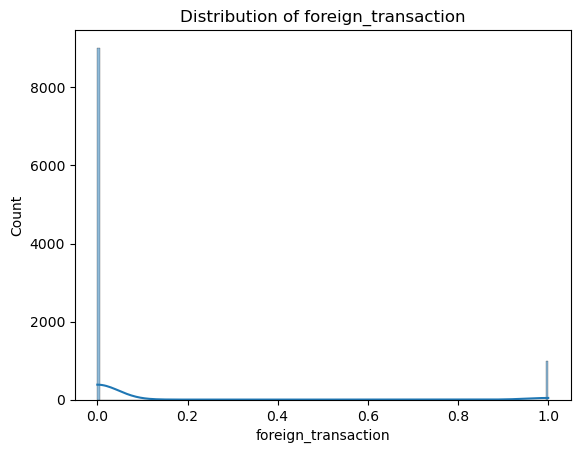

Skewness of foreign_transaction = 2.71


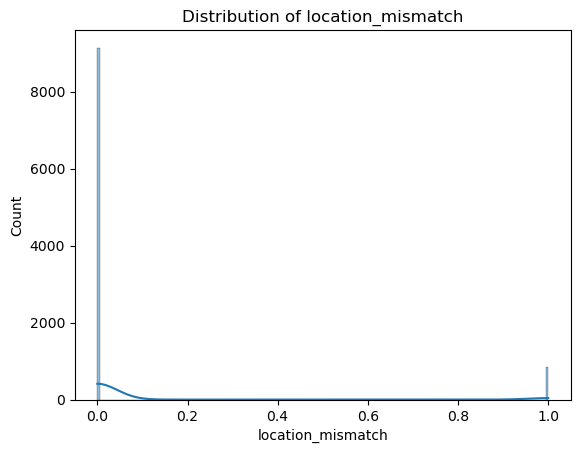

Skewness of location_mismatch = 2.96


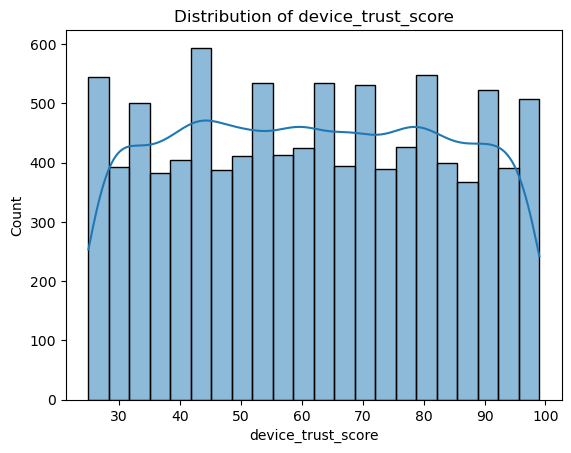

Skewness of device_trust_score = 0.01


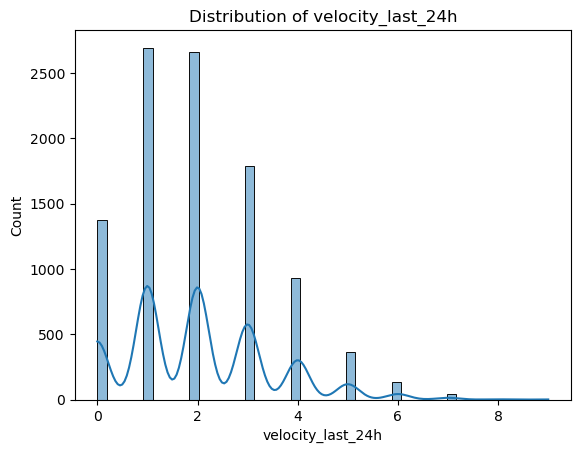

Skewness of velocity_last_24h = 0.71


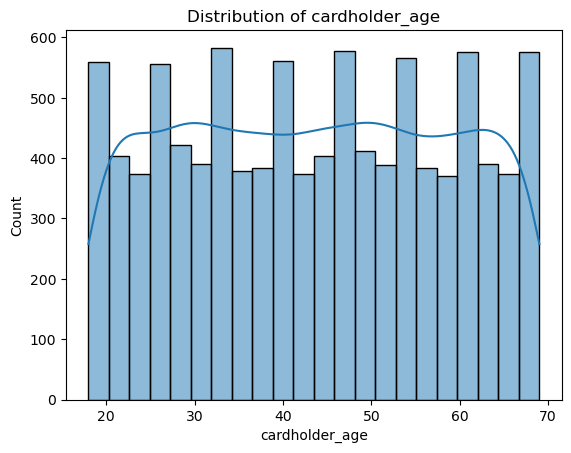

Skewness of cardholder_age = 0.0


In [180]:
num_cols = list(df.select_dtypes(include='number').columns)
num_cols.remove('is_fraud')
for col in num_cols:
        sns.histplot(df[col], kde=True,)
        plt.title(f"Distribution of {col}")
        plt.show()
        print(f"Skewness of {col} = {(df[col].skew()).round(2)}")

Skewness of `amount` column is high, so we will take log value for this column.
Other Columns like `location_mismatch` and `foriegn_transaction` also have high skewness but we will not take log value for those features since they represent yes or no and not value.

In [181]:
df['amount'] = np.log1p(df.amount)
df.amount.skew()

np.float64(-0.7969804420148893)

In [182]:
df.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,4.448165,22,Electronics,0,0,66,3,40,0
1,6.296778,3,Travel,1,0,87,1,64,0
2,5.472313,17,Grocery,0,0,49,1,61,0
3,5.107943,4,Grocery,0,1,72,3,34,0
4,3.450939,15,Food,0,0,79,0,44,0


Text(0.5, 1.0, 'Distribution of Merchant Catagpries')

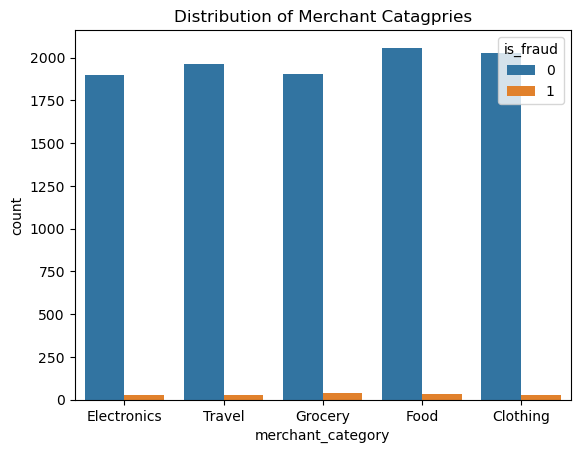

In [183]:
sns.countplot(x=df.merchant_category, hue=df.is_fraud)
plt.title("Distribution of Merchant Catagpries")

It is almost evenly distributed.

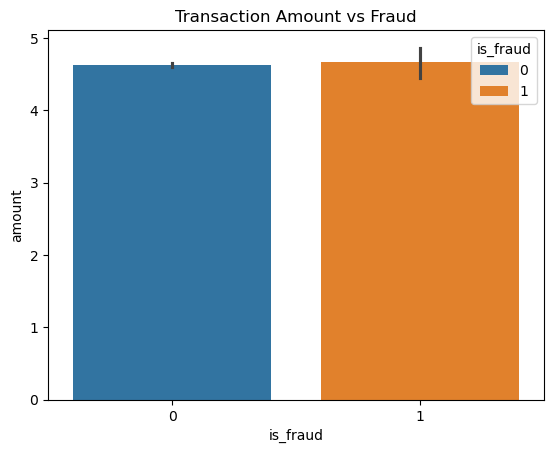

In [184]:
sns.barplot(data=df, x='is_fraud', y='amount', hue='is_fraud')
plt.title('Transaction Amount vs Fraud')
plt.show()

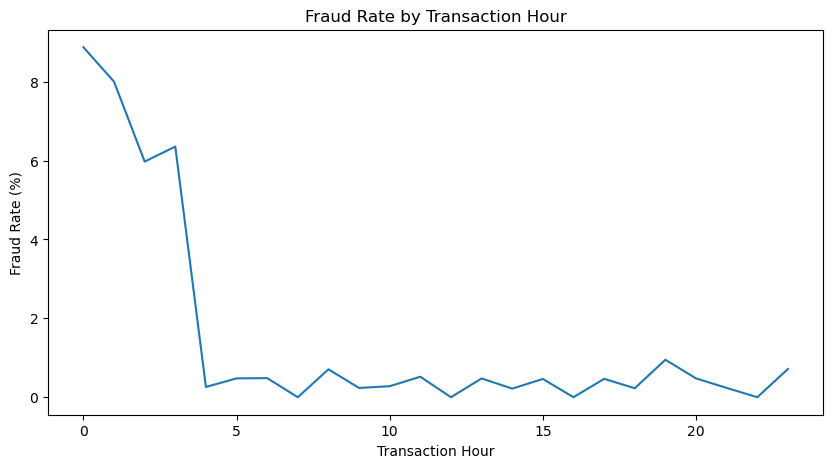

In [185]:
hour_fraud = df.groupby('transaction_hour')['is_fraud'].mean() * 100
hour_fraud.plot(figsize=(10, 5))
plt.ylabel('Fraud Rate (%)')
plt.xlabel('Transaction Hour')
plt.title('Fraud Rate by Transaction Hour')
plt.show()

Here we can see that, Mostly fraud transaction occurs at night between time 0 - 4.

In [186]:
fraud_rate = df.groupby('merchant_category')['is_fraud'].mean() * 100
print(fraud_rate.sort_values(ascending=False))

merchant_category
Grocery        2.006173
Food           1.672241
Travel         1.457286
Electronics    1.248050
Clothing       1.170732
Name: is_fraud, dtype: float64


This shows that the Grocery Merchant has more fraud rate.

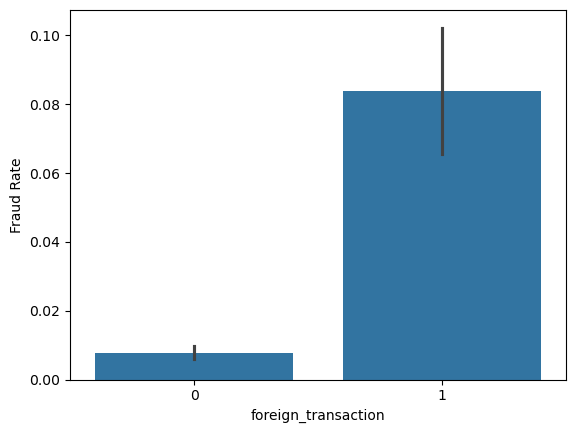

In [187]:
sns.barplot(x = df.foreign_transaction, y=df.is_fraud)
plt.ylabel('Fraud Rate')
plt.show()

This shows that when there are foriegn transaction there is more chance of fraud.

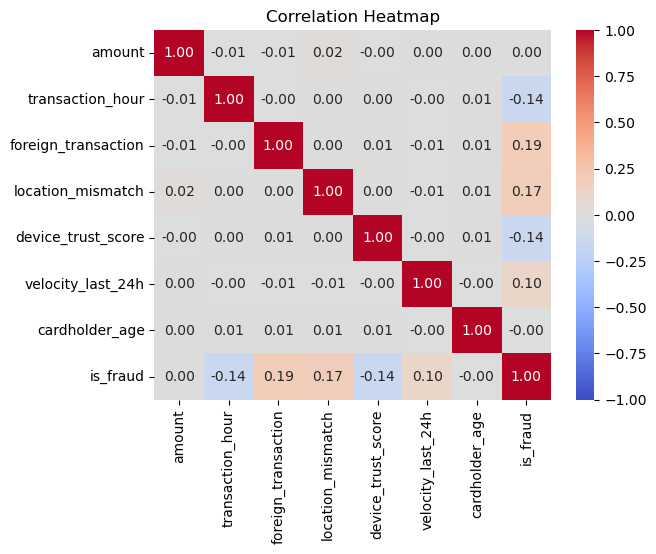

In [188]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

This shows that there is no Linear Relation between columns.

**EDA Takeaways:**
1. Fraud Transaction are mostly done at night.
2. Most Fraud is carried out by Grocery Merchant.
3. Target Class is Imbalanced

## 5. Data Cleaning and Preprocessing

In [189]:
le = LabelEncoder()
df['merchant_category'] = le.fit_transform(df.merchant_category)
df.sample(4)

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
5004,5.907431,0,3,0,0,27,0,44,0
8394,5.636039,4,4,0,0,58,4,34,0
570,4.874204,8,3,0,0,61,2,64,0
9084,4.289226,15,3,0,0,38,2,20,0


In [190]:
X = df.drop('is_fraud', axis=1)
y = df.is_fraud

In [191]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
xtrain.shape,ytest.shape

((7500, 8), (2500,))

In [192]:
upsample = SMOTE()
xtrain,ytrain = upsample.fit_resample(xtrain,ytrain)
ytrain.value_counts(normalize=True)

is_fraud
0    0.5
1    0.5
Name: proportion, dtype: float64

In [193]:
scaling_cols = ['amount','device_trust_score','cardholder_age']
scaler = StandardScaler()
preprocessor = ColumnTransformer([
    ('StandardScaler',scaler,scaling_cols)
],remainder='passthrough')
xtrain = preprocessor.fit_transform(xtrain)
xtest = preprocessor.transform(xtest)

In [194]:
xtrain_df = pd.DataFrame(xtrain, columns=preprocessor.get_feature_names_out())
xtrain_df.head()

,StandardScaler__amount,StandardScaler__device_trust_score,StandardScaler__cardholder_age,remainder__transaction_hour,remainder__merchant_category,remainder__foreign_transaction,remainder__location_mismatch,remainder__velocity_last_24h
0,1.119623,1.716854,-0.400104,20.0,2.0,0.0,0.0,2.0
1,0.215841,-0.920267,-0.129513,15.0,0.0,0.0,0.0,2.0
2,-0.533944,-1.052123,1.764628,14.0,1.0,1.0,0.0,0.0
3,-0.335607,1.804758,0.411670,3.0,1.0,0.0,0.0,2.0
4,-1.698522,0.618053,1.291093,22.0,1.0,0.0,0.0,4.0


## 6. Training Models

In [195]:
models = {
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'RandomForestClassifier':RandomForestClassifier(),
    'XGBClassifier':XGBClassifier(),
    'LogisticRegression':LogisticRegression(),
    'SVC':SVC()
}

In [196]:
def check_score(y_pred_test,y_test,y_pred_train,y_train):
    acctest = accuracy_score(y_test,y_pred_test)
    acctrain = accuracy_score(y_train,y_pred_train)
    rectest = recall_score(y_test,y_pred_test)
    rectrain = recall_score(y_train,y_pred_train)
    pretest = precision_score(y_test,y_pred_test)
    pretrain = precision_score(y_train,y_pred_train)
    roctest = roc_auc_score(y_test,y_pred_test)
    roctrain = roc_auc_score(y_train,y_pred_train)
    f1test = f1_score(y_test,y_pred_test)
    f1train = f1_score(y_train,y_pred_train)
    return acctest,acctrain,rectest,rectrain,pretest,pretrain,roctest,roctrain,f1test,f1train

In [197]:
res = []
for name,mod in models.items():
    model = mod
    model.fit(xtrain,ytrain)
    ytest_pred = model.predict(xtest)
    ytrain_pred = model.predict(xtrain)
    acctest,acctrain,rectest,rectrain,pretest,pretrain,roctest,roctrain,f1test,f1train = check_score(ytest_pred,ytest,ytrain_pred,ytrain)
    res.append({
                'Model Name':name,
                'Model':model,
                'Accuracy Test':acctest,
                'Accuracy Train':acctrain,
                'Recall Test':rectest,
                'Recall Train':rectrain,
                'Precision Test':pretest,
                'Precision Train':pretrain,
                'ROC AUC Test':roctest,
                'ROC AUC Train':roctrain,
                'F1 Score Test':f1test,
                'F1 Score Train':f1train
            })
    print(f"{name} Model Trained Sucessfully.")

KNeighborsClassifier Model Trained Sucessfully.
DecisionTreeClassifier Model Trained Sucessfully.
RandomForestClassifier Model Trained Sucessfully.
XGBClassifier Model Trained Sucessfully.
LogisticRegression Model Trained Sucessfully.
SVC Model Trained Sucessfully.


## 7. Comparing the Models based on Performance Metrices

In [198]:
result = pd.DataFrame(res).sort_values(by='ROC AUC Test',ascending=False).reset_index(drop=True)
result_df = result.drop('Model',axis=1)
result_df 

,Model Name,Accuracy Test,Accuracy Train,Recall Test,Recall Train,Precision Test,Precision Train,ROC AUC Test,ROC AUC Train,F1 Score Test,F1 Score Train
0,SVC,0.9120,0.951063,0.973684,0.985244,0.144531,0.922200,0.942366,0.951063,0.251701,0.952680
1,LogisticRegression,0.8828,0.910383,0.947368,0.935562,0.110092,0.890708,0.914586,0.910383,0.197260,0.912584
2,XGBClassifier,0.9752,0.999255,0.842105,1.000000,0.363636,0.998513,0.909680,0.999255,0.507937,0.999256
3,KNeighborsClassifier,0.9328,0.974144,0.868421,0.998376,0.168367,0.952227,0.901107,0.974144,0.282051,0.974755
4,RandomForestClassifier,0.9780,1.000000,0.815789,1.000000,0.392405,1.000000,0.898147,1.000000,0.529915,1.000000
5,DecisionTreeClassifier,0.9668,1.000000,0.657895,1.000000,0.263158,1.000000,0.814731,1.000000,0.375940,1.000000


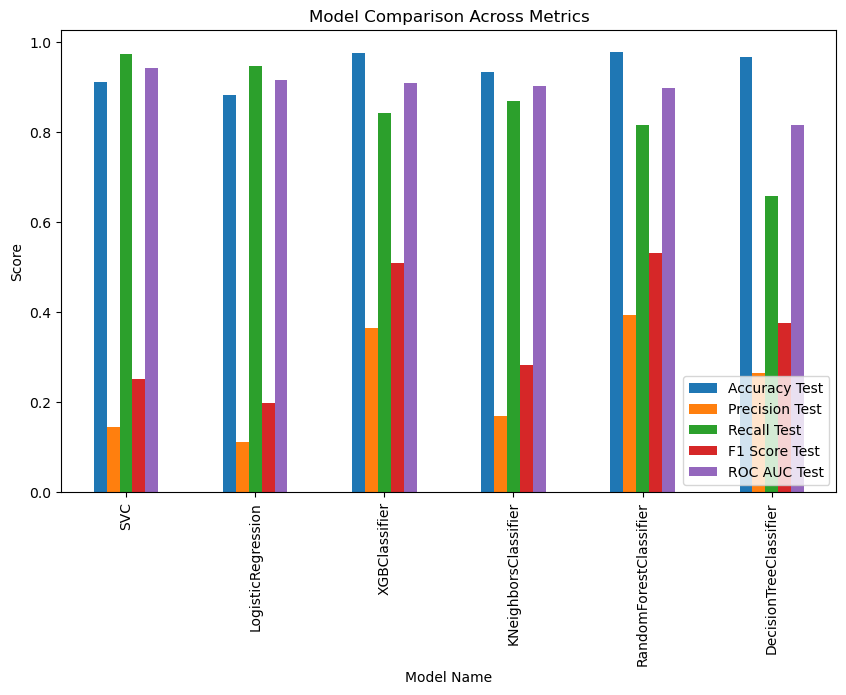

In [199]:
# Visual comparision of Metrices
result.set_index("Model Name")[["Accuracy Test", "Precision Test", "Recall Test", "F1 Score Test", "ROC AUC Test"]].plot(
    kind='bar', figsize=(10, 6)
)
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xticks(rotation=90)
plt.legend(loc='lower right')
plt.show()

## 8. Select and Justify the Best Model

**Selection Logic :** Looking at the comparison table above, the **SVC** model typically achieves the highest `Recall Score` and `ROC-AUC Score` among all the models. We chose the model based on Recall because in this case False Negative is more Harmful than false positive.

In [200]:
best_model_name = result_df.iloc[0]["Model Name"]
best_model = result.iloc[0]['Model']
print(f"Best Model : {best_model_name}")

Best Model : SVC


## 9. Hyper-parameter Tuning

In [201]:
param = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'class_weight': [None, 'balanced']
}
tuner = GridSearchCV(best_model, param_grid=param)
tuner.fit(xtrain,ytrain)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'class_weight': [None, 'balanced'], 'kernel': ['rbf', 'linear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [202]:
tuner.best_params_

{'C': 10, 'class_weight': None, 'kernel': 'rbf'}

In [203]:
svc = SVC(C=10, class_weight=None, kernel='rbf')
svc.fit(xtrain, ytrain)
ybest_test_pred = svc.predict(xtest)
ybest_train_pred = svc.predict(xtrain)
print(f"Test : {recall_score(ytest,ybest_test_pred)}")
print(f"Train : {recall_score(ytrain,ybest_train_pred)}")

Test : 0.9473684210526315
Train : 0.988357926086368


In [204]:
print(classification_report(ytest,ybest_test_pred, target_names=['No','Yes']))

              precision    recall  f1-score   support

          No       1.00      0.93      0.96      2462
         Yes       0.16      0.95      0.28        38

    accuracy                           0.93      2500
   macro avg       0.58      0.94      0.62      2500
weighted avg       0.99      0.93      0.95      2500



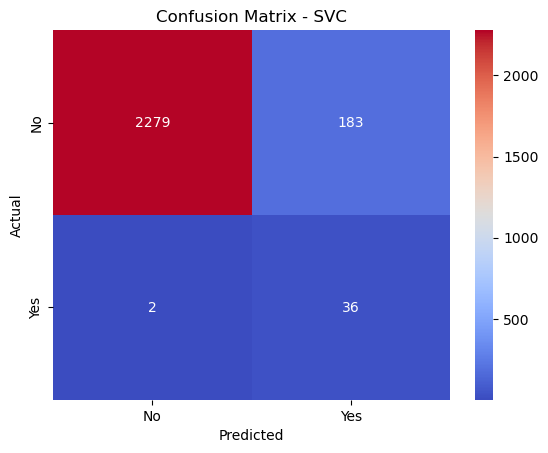

In [205]:
cm = confusion_matrix(ytest,ybest_test_pred)
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='d', yticklabels=['No','Yes'],xticklabels=['No','Yes'])
plt.title('Confusion Matrix - SVC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Here We can see that this model has very less False Negative compare to False Positive.

## 10. Testing on Unseen Data

In [211]:
unseendata = xtrain_df.sample(5)
predections = svc.predict(unseendata)
results_unseen = unseendata.copy()
results_unseen['Predicted_Class'] = np.where(predections == 1, 'Yes', 'No')
results_unseen.Predicted_Class

11930    Yes
12335    Yes
9218     Yes
2276      No
4317      No
Name: Predicted_Class, dtype: object

## 11. Conclusion

- Trained and compared multiple classification models.
- The best-performing model was selected based on Recall Score, given the medical context.
- The selected model was used to predict on unseen samples successfully.